# UAV LiDAR → DTM / DSM / CHM Workflow
**Ground classification via CSF (Zhang et al. 2016) and TIN interpolation**

## Overview

This workflow processes a UAV LiDAR `.las` file through the following
steps:

1.  Load and inspect the point cloud
2.  Classify ground points using the **Cloth Simulation Filter (CSF)**
3.  Generate a **Digital Terrain Model (DTM)** via TIN interpolation
4.  Height-normalize the point cloud
5.  Generate a **Digital Surface Model (DSM)** from first returns
6.  Subtract to produce a **Canopy Height Model (CHM)**
7.  Clip to the boundary of the Area of Interest
8.  Summarize canopy height statistics

---

## Setup

Install required packages if you haven't already:

In [ ]:
install.packages(c("terra", "RCSF", "sf"))

In [1]:
library(terra)
library(sf)
library(RCSF)
library(lidR)

out_dir <- readline(prompt = "Enter output folder path: ")
cat("Saving outputs to:", out_dir, "\n")

terra 1.9.50

Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.1; sf_use_s2() is TRUE


Attaching package: 'lidR'


The following object is masked from 'package:sf':

    st_concave_hull


The following object is masked from 'package:terra':

    watershed




Saving outputs to: D:\OusterData\Bartleson\Raw_Bartleson_Files_9_22_2026\wind turbine files 


---

## 1. Load the Point Cloud 

(Takes ~10 minutes depending on file size)

`file.choose()` opens a native OS file browser so you can navigate to
your `.las` or `.laz` file interactively, rather than hardcoding a path.

> **Note:** the dialog may open behind your RStudio window — check your
> taskbar. On Mac, this requires R to be run in GUI mode (not
> terminal-only).

In [14]:
message("Please select your LAS or LAZ file in the file browser.")

las_path <- file.choose()
cat("Selected file:", las_path, "\n")

las <- readLAS(las_path,
               select = "xyzrci",        # load x, y, z, return number, classification, intensity
               filter = "-drop_z_below 0")  # drop obviously bad points below ground

# Quick check: point count, CRS, classification status
print(las)
las_check(las)   # flags issues like duplicates, wrong return counts, etc.

Please select your LAS or LAZ file in the file browser.



Selected file: D:\OusterData\Bartleson\Raw_Bartleson_Files_9_22_2026\125cm_min_range_Bart_EucTree_20260922_1035_16_.las 


Warning message:
"Invalid data: 10762244 points with a return number equal to 0 found."


class        : LAS (v1.2 format 3)
memory       : 328.4 Mb 
extent       : -209.44, 206.91, -185.15, 176.84 (xmin, xmax, ymin, ymax)
coord. ref.  : NA 
area         : 22016 units²
points       : 10.76 million points
type         : airborne
density      : 488.84 points/units²

 Checking the data
  - Checking coordinates... ✓
  - Checking coordinates type... ✓
  - Checking coordinates range... ✓
  - Checking coordinates quantization... ✓
  - Checking attributes type... ✓
  - Checking ReturnNumber validity...
    ⚠ Invalid data: 10762244 points with a return number equal to 0 found.
  - Checking NumberOfReturns validity... ✓
  - Checking ReturnNumber vs. NumberOfReturns... ✓
  - Checking RGB validity... ✓
  - Checking absence of NAs... ✓
  - Checking duplicated points...
    ⚠ 26468 points are duplicated and share XYZ coordinates with other points
  - Checking degenerated ground points... skipped
  - Checking attribute population... ✓
  - Checking gpstime incoherances skipped
  - Checking

Warning message:
"Zero last return found. Cannot use the option 'last_returns', all the points will be used."
Original dataset already contains 519335 ground points. These points were reclassified as 'unclassified' before performing a new ground classification.



Tilt (deg): 0.9093296 


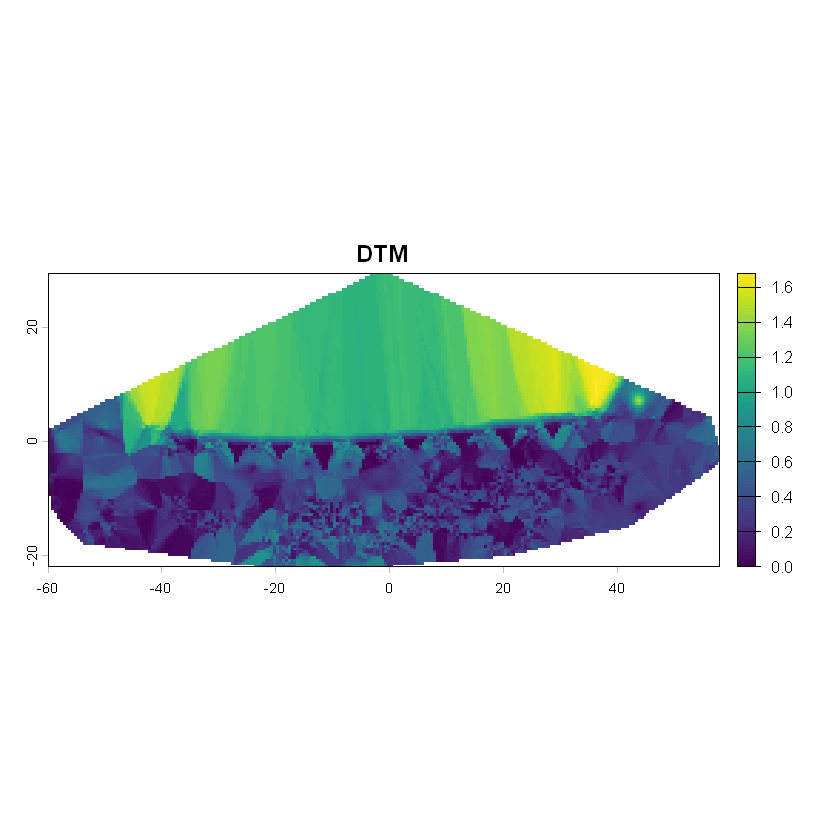

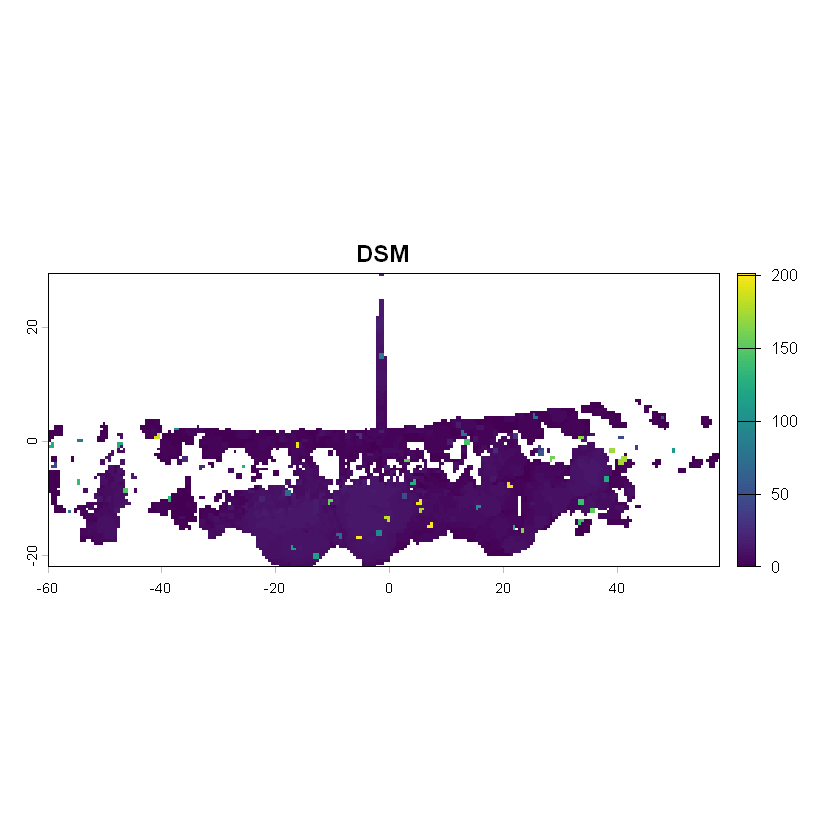

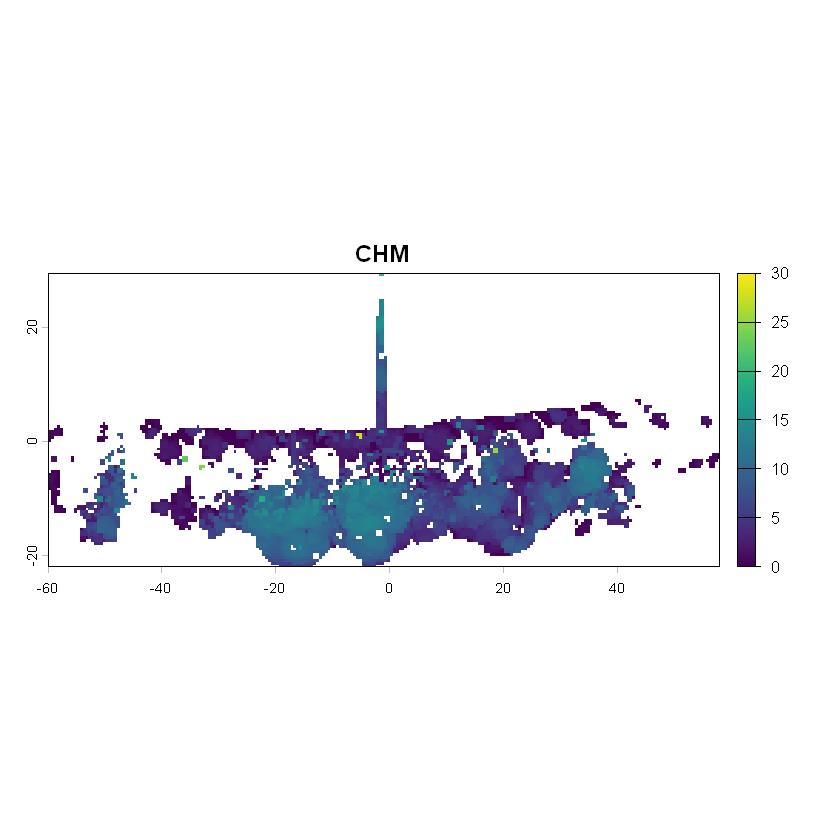

In [16]:
data.table::set(las@data, j = "ReturnNumber", value = 1L)
data.table::set(las@data, j = "NumberOfReturns", value = 1L)
las <- filter_duplicates(las)

# Keep area with good coverage (sensor at 0,0)
# las <- clip_circle(las, 0, 0, 60)

# Ground classification (coarser cloth for sparse ground)
# Classify ground on full cloud first
las <- classify_ground(las, csf(cloth_resolution = 1, class_threshold = 0.3))

# Outline of where ground points exist
gnd  <- filter_ground(las)
hull <- st_concave_hull(gnd, method = "concaveman", concavity = 2, length_threshold = 5)

# Clip everything to that outline
las <- clip_roi(las, hull)
gnd <- filter_ground(las) 

# Tilt check: fit plane to ground
fit <- lm(Z ~ X + Y, data = gnd@data)
cat("Tilt (deg):", atan(sqrt(coef(fit)[2]^2 + coef(fit)[3]^2)) * 180 / pi, "\n")

# DTM, normalize, DSM, CHM
dtm  <- rasterize_terrain(las, res = 0.5, knnidw())
nlas <- normalize_height(las, dtm)
nlas <- filter_poi(nlas, Z >= 0)
dsm  <- rasterize_canopy(las,  res = 0.5, p2r(0.2))
chm  <- rasterize_canopy(nlas, res = 0.5, p2r(0.2))

# View
plot(dtm, main = "DTM")
plot(dsm, main = "DSM")
plot(chm, range = c(0, 30), main = "CHM")

In [ ]:
library(lidR)

# Load
las <- readLAS(file.choose())

# Fix Ouster return numbers + remove duplicates
las$ReturnNumber <- 1L
las$NumberOfReturns <- 1L
las <- filter_duplicates(las)

# Check orientation (Z should point up)
plot(las)

# Ground classification
las <- classify_ground(las, csf(cloth_resolution = 0.5, class_threshold = 0.2))

# DTM
dtm <- rasterize_terrain(las, res = 1, tin())

# Normalize, keep turbine, drop below-ground noise
nlas <- normalize_height(las, dtm)
nlas <- filter_poi(nlas, Z >= 0)

# DSM (unnormalized) and CHM
dsm <- rasterize_canopy(las, res = 0.5, p2r(0.2))
chm <- rasterize_canopy(nlas, res = 0.5, p2r(0.2))

# View (cap color scale so trees are visible)
plot(dtm)
plot(dsm)
plot(chm, range = c(0, 30))

In [ ]:
las$ReturnNumber <- 1L
las$NumberOfReturns <- 1L
las <- filter_duplicates(las)

las <- classify_ground(las, csf(cloth_resolution = 0.5, class_threshold = 0.2))
dtm <- rasterize_terrain(las, res = 1, tin())
nlas <- normalize_height(las, dtm)
nlas <- filter_poi(nlas, Z >= 0 & Z < 50)   # drop noise/turbine
chm <- rasterize_canopy(nlas, res = 0.5, p2r(0.2))
plot(chm)

---

## 2. Ground Classification with CSF

CSF or CLoth Simulation Filtering (Zhang et al. 2016) simulates a cloth dropped over an **inverted**
point cloud. The cloth drapes down under gravity and the points that end
up close to the cloth are labelled as ground.

Key parameters:

| Parameter | What it controls |
|------------------------------------|------------------------------------||
| `sloop_smooth` | Post-processing step to recover ground points on steep slopes. `FALSE` for flat terrain. |
| `class_threshold` | Max distance (m) a point can be from the cloth to still be called ground |
| `cloth_resolution` | Grid cell size of the simulated cloth (m) — smaller = finer detail, slower |
| `rigidness` | How much the cloth resists bending: 1 = flexible (hilly), 2 = medium, 3 = rigid (flat) |
| `iterations` | More iterations = cloth drapes more accurately, but slower |
| `time_step` | Internal physics timestep — leave at default 0.65 |

In [ ]:
las <- classify_ground(
  las,
  algorithm = csf(
    sloop_smooth     = FALSE,  # FALSE for flat/gentle terrain
    class_threshold  = 0.5,    # points within 0.5 m of cloth are classified as ground # nolint: line_length_linter.
    cloth_resolution = 0.5,    # cloth cell size in metres
    rigidness        = 2,      # 2 = medium; use 3 for very flat/open terrain
    iterations       = 500,
    time_step        = 0.65
  )
)

---

## 3. DTM via Adaptive Triangulation

`rasterize_terrain()` converts the ground-classified points into a
continuous raster elevation surface — the DTM.

**How TIN interpolation works:**

1.  Takes all ground-classified points
2.  Connects them into a mesh of non-overlapping triangles (Delaunay
    triangulation)
3.  Triangle sizes naturally adapt to local point density — smaller
    where points are dense, larger where they are sparse. This is the
    "adaptive" part.
4.  For each output raster cell, elevation is interpolated from the
    plane defined by the three vertices of whichever triangle contains
    that cell centre.

This approach honours every ground point exactly without smoothing,
making it the most accurate method for DTM generation from lidar. It is
equivalent to what Mishra & Singh (2026) describe as "adaptive
triangulation."

In [ ]:
dtm <- lidR::rasterize_terrain(
  las,
  res       = 1,      # 0.4m output pixel size (following Fu et al.(2025) paper)
  algorithm = lidR::tin()   # Delaunay TIN built from ground-clas points
)

# Alternative: IDW — faster but slightly smoother/less faithful to ground points
# dtm <- rasterize_terrain(las, res = 0.25, algorithm = knnidw(k = 10, p = 2))

writeRaster(dtm, file.path(out_dir, "oust_low_1.0m_dtm.tif"), overwrite = TRUE)
cat("DTM written to oust_low_1.0m_dtm.tif\n")

---

## 4. Height-Normalise the Point Cloud

Subtracts the DTM elevation from every point's Z value, so that ground
points become Z ≈ 0 and all other points represent **height above
ground** rather than height above sea level.

In [ ]:
las_norm <- normalize_height(las, algorithm = tin())

# Sanity check: ground points should now cluster near Z = 0
hist(filter_ground(las_norm)$Z, main = "Ground point heights after normalisation")

---

## 5. DSM from First Returns

The DSM represents the highest surface the lidar pulse hits — treetops,
rooftops, etc. Using only **first returns** ensures we capture the top
of the canopy rather than pulses that penetrated through gaps.

In [ ]:
las_first <- filter_poi(las, ReturnNumber == 1L)

dsm <- rasterize_canopy(
  las_first,
  res       = 1,
  algorithm = p2r(subcircle = 0.1)  # point-to-raster; subcircle fills tiny gaps
  # Smoother alternative:
  # algorithm = dsmtin()
)

writeRaster(dsm, file.path(out_dir, "oust_low_1.0m_dsm.tif"), overwrite = TRUE)
cat("DSM written to oust_low_1.0m_dsm.tif\n")

---

## 6. CHM = DSM − DTM

Subtracting the DTM from the DSM removes terrain elevation, leaving only
**canopy height above ground**.

In [ ]:
# Align extents before subtracting (should already match, but just in case)
dtm_aligned <- resample(dtm, dsm, method = "bilinear")

chm <- dsm - dtm_aligned

# Clamp negative values to 0 (artefacts where DSM dips below DTM)
chm <- clamp(chm, lower = 0, values = TRUE)

writeRaster(chm, file.path(out_dir, "chm_1.0m.tif"), overwrite = TRUE)
cat("CHM written to chm_1.0m.tif\n")

---

## 7. Clip to AOI Boundary

In [ ]:
# Step 1: pop-up folder picker for the .gdb
gdb_path <- tcltk::tk_choose.files(caption = "Select your .gdb folder or .gpkg file") # change to choose.dir() if you want to select a folder instead of a file

# Step 2: list all layers and print them
layers <- st_layers(gdb_path)$name
cat("Layers found in geodatabase:\n")
for (i in seq_along(layers)) {
  cat(i, ":", layers[i], "\n")
}

# Step 3: type the number of the layer you want in the console when prompted
layer_index <- as.integer(readline(prompt = "Enter the number of the layer to use: "))
layer_name  <- layers[layer_index]
cat("Using layer:", layer_name, "\n")

# Step 4: read and reproject to match CHM
boundary <- st_read(gdb_path, layer = layer_name, quiet = TRUE)
boundary <- st_transform(boundary, crs = terra::crs(chm))

# Step 5: clip
chm_clipped <- mask(crop(chm, vect(boundary)), vect(boundary))

writeRaster(chm_clipped, file.path(out_dir, "bart_chm_1m_clipped.tif"), overwrite = TRUE)
cat("Clipped CHM written to bart_chm_1m_clipped.tif\n")

## 7b. Extract AOI Bounding Box for GEDI Data Pull

Reprojects the boundary to WGS84 (lat/long) and prints the bounding box
coordinates you can copy directly into your Python GEDI data pull
script.

In [ ]:
# # Reproject boundary to WGS84 (EPSG:4326) for lat/long coordinates
# boundary_wgs84 <- st_transform(boundary, crs = 4326)

# # Get bounding box
# bb <- st_bbox(boundary_wgs84)

# cat("── AOI Bounding Box (WGS84) ──────────────────\n")
# cat(sprintf("  Min Longitude (West)  : %.6f\n", bb["xmin"]))
# cat(sprintf("  Max Longitude (East)  : %.6f\n", bb["xmax"]))
# cat(sprintf("  Min Latitude  (South) : %.6f\n", bb["ymin"]))
# cat(sprintf("  Max Latitude  (North) : %.6f\n", bb["ymax"]))
# cat("──────────────────────────────────────────────\n")
# cat("\nPython-ready (copy-paste):\n")
# cat(sprintf("LAT_MIN, LAT_MAX = %.3f, %.3f\nLON_MIN, LON_MAX = %.3f, %.3f\n",
#             bb["ymin"], bb["ymax"], bb["xmin"], bb["xmax"]))

---

## 8. Summary Statistics

Canopy height percentiles, matching the GEDI RH metric comparisons used
in Mishra & Singh (2026): RH95 ↔ P95, RH98 ↔ P98, etc.

In [ ]:
cat("\n── CHM summary (clipped) ──\n")
print(summary(values(chm_clipped), na.rm = TRUE))

chm_vals <- values(chm_clipped, na.rm = TRUE)
cat(sprintf("P95  = %.2f m\n", quantile(chm_vals, 0.95)))
cat(sprintf("P98  = %.2f m\n", quantile(chm_vals, 0.98)))
cat(sprintf("P99  = %.2f m\n", quantile(chm_vals, 0.99)))
cat(sprintf("P100 = %.2f m\n", max(chm_vals)))

---

## 9. Plot

In [ ]:
par(mfrow = c(1,1))
plot(dtm,         main = "DTM (1 m)",         col = terrain.colors(100))
plot(dsm,         main = "DSM (1.0 m)",         col = terrain.colors(100))
plot(chm, main = "CHM (1.0 m)", col = height.colors(100))
plot(chm_clipped, main = "Clipped CHM (1 m)", col = height.colors(100))


---

## References

Zhang, W., Qi, J., Wan, P., Wang, H., Xie, D., Wang, X., & Yan, G.
(2016). An easy-to-use airborne LiDAR data filtering method based on
cloth simulation. *Remote Sensing*, 8(6), 501.
<https://doi.org/10.3390/rs8060501>

Mishra, N. B., & Singh, P. B. (2026). Mountains of error: UAV LiDAR
benchmarking of GEDI and GEDI-derived global canopy height products in
steep Himalayan forests. *International Journal of Applied Earth
Observation and Geoinformation*, 147, 105203.

Yuwen Fu, Wang Li, Wensheng Duan, Jie Bai, Li Wang & Zheng Niu
(2025) Comparison of UAV-LiDAR-driven biomass estimation approaches in planted forests
with different management, International Journal of Digital Earth, 18:2, 2576910, DOI:
10.1080/17538947.2025.2576910
